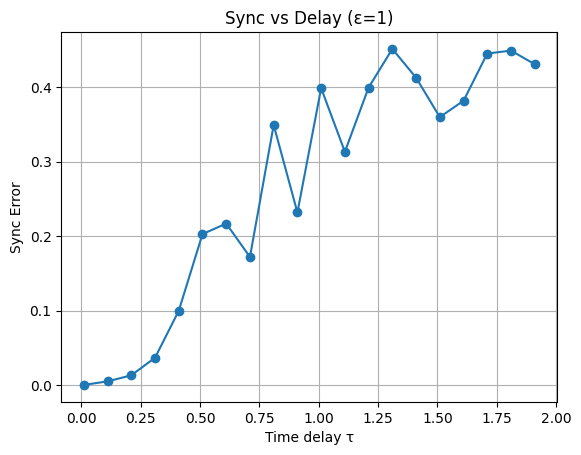

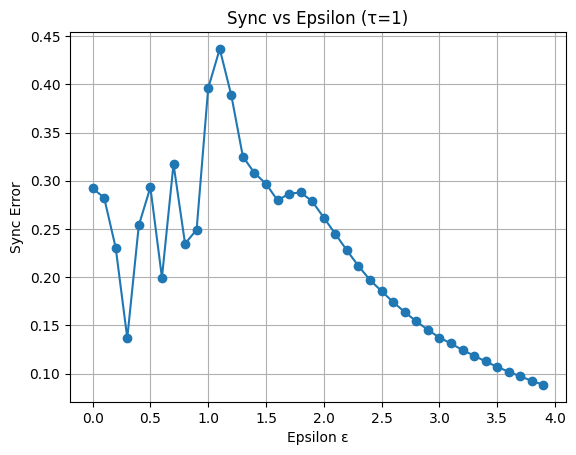

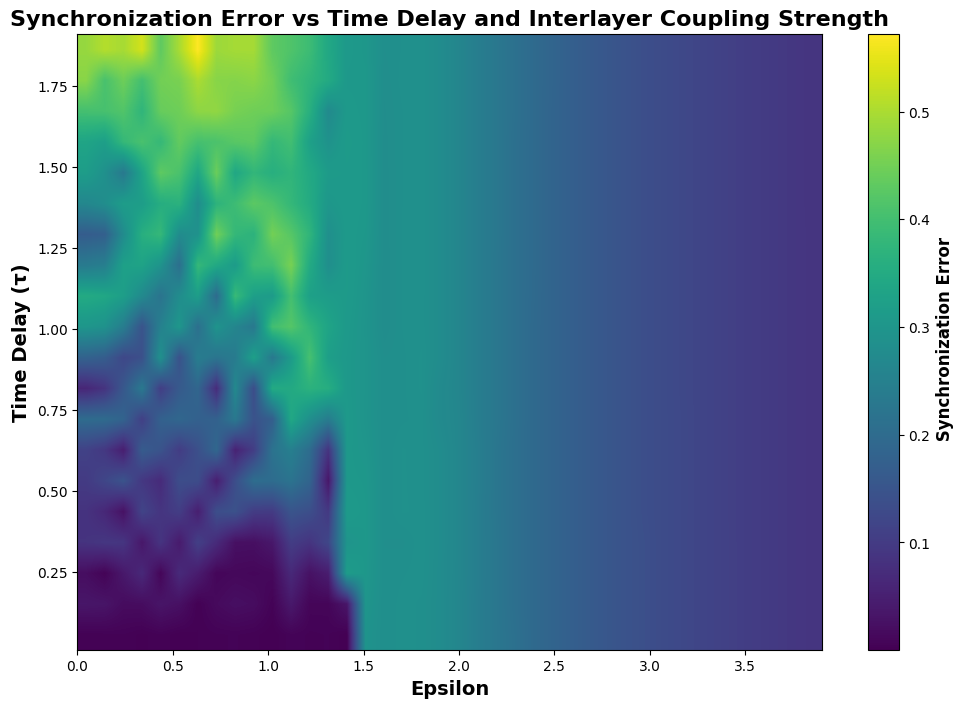

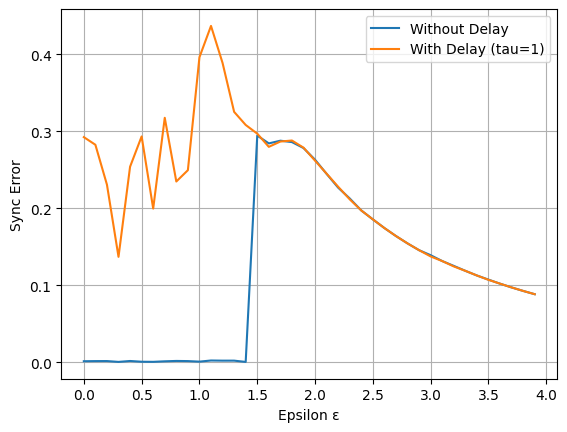

Critical Coupling (no delay): 0.0  and minimum error: 0.0003502572385956104
Critical Coupling (with delay): None and minimum error : 0.08829011148569942


In [5]:
#L1-random, L2-ring
#ring to random network (environment is ring  and oscillator network  is random  network)
#multiplexed network
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
#parameters
N = 100            # number of oscillators
r1 = 5           #for environment
p=0.1          # coupling range for oscillators in layer 2 (connection probability for erdos renyi random network)
omega = 1.0        # natural frequency
h = 0.01          # time step
T = 100           # total time
k1=0.5
k2=0.5
gamma=1  #damping coefficient
steps =int(T / h)

#generate ER network
G_random=nx.erdos_renyi_graph(N,p,seed=0)
A_random=nx.to_numpy_array(G_random)
degree_random=np.sum(A_random,axis=1)
#generate Ring network(Wattss strogatz network with beta=0)
G_ring = nx.watts_strogatz_graph(N, 2*r1, 0)
A_ring=nx.to_numpy_array(G_ring)
degree_ring=np.sum(A_ring,axis=1)

#initial conditions with reproducibility
np.random.seed(0)
x0=np.random.uniform(-1,1,N)
y0=np.random.uniform(-1,1,N)
s0=np.random.uniform(-1,1,N)
#tau and k1 values
tau_values = np.arange(0.01, 2, 0.1)
epsilon_values = np.arange(0,4,0.1)
#ODE function
def diff_eqn(x, x_delayed, y,s,epsilon,k2, k1,A_ring,A_random):
    dx = np.zeros(N)
    dy = np.zeros(N)
    ds  = np.zeros(N)
    sum_1=A_ring@s-degree_ring*s
    sum_2=A_random@x_delayed-degree_random*x

    dx = (1 - x**2 - y**2) * x - omega * y + (k1 / np.mean(degree_random)) * sum_2+epsilon*s
    dy = (1 - x**2 - y**2) * y + omega * x
    ds= -gamma*s-epsilon*x+(k2/np.mean(degree_ring))*sum_1


    return dx, dy,ds


def rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_random):

    k1_x, k1_y, k1_s = diff_eqn(x,x_delayed, y,s,epsilon, k2, k1,A_ring,A_random)
    k2_x, k2_y, k2_s = diff_eqn(x + 0.5*h*k1_x,x_delayed, y + 0.5*h*k1_y,s + 0.5*h*k1_s,epsilon, k2, k1,A_ring,A_random)
    k3_x, k3_y, k3_s = diff_eqn(x + 0.5*h*k2_x,x_delayed, y + 0.5*h*k2_y,s + 0.5*h*k2_s,epsilon, k2, k1,A_ring,A_random)
    k4_x, k4_y, k4_s = diff_eqn(x + h*k3_x, x_delayed, y + h*k3_y,s + h*k3_s,epsilon, k2, k1,A_ring,A_random)

    x_new = x + (h / 6) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    y_new = y + (h / 6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    s_new = s + (h / 6) * (k1_s + 2*k2_s + 2*k3_s + k4_s)

    return x_new, y_new, s_new


#to run simulation
def simulator(x0, y0,s0, tau, k1,k2,epsilon,A_ring,A_random):
    time_delay_steps = int(tau / h)

    x_history = [x0.copy()]
    y_history = [y0.copy()]
    s_history = [s0.copy()]

    for iteration in range(steps - 1):

        if iteration < time_delay_steps:
            x_delayed = x0
        else:
            x_delayed = x_history[iteration - time_delay_steps]

        x = x_history[iteration]
        y = y_history[iteration]
        s=  s_history[iteration]

        xnew, ynew,snew = rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_random)

        x_history.append(xnew)
        y_history.append(ynew)
        s_history.append(snew)

    return np.array(x_history), np.array(y_history),np.array(s_history)

  #synchronistion error calculated between the two layers
  #for one case when no delay and then when there is a delay




#synchronisation matrix
sync_matrix = np.zeros((len(tau_values), len(epsilon_values)))

for i in range(len(tau_values)):
    for j in range(len(epsilon_values)):

        x_hist, _,s_hist = simulator(x0, y0,s0, tau_values[i], k1,k2,epsilon_values[j],A_ring,A_random)


        sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
        sync_matrix[i, j] = sync_error






# SYNC ERROR vs TAU
epsilon_fixed = 1
sync_vs_tau = []

for tau in tau_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau, k1, k2, epsilon_fixed,A_ring,A_random)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))  # scalar
    sync_vs_tau.append(sync_error)                              # append scalar directly

plt.figure()
plt.plot(tau_values, sync_vs_tau, 'o-')
plt.xlabel('Time delay τ')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Delay (ε={epsilon_fixed})')
plt.grid(True)
plt.show()

# SYNC ERROR vs EPSILON
tau_fixed = 1
sync_vs_epsilon = []

for epsilon in epsilon_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, epsilon,A_ring,A_random)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1]))) # scalar
    sync_vs_epsilon.append(sync_error)                          # append scalar directly

plt.figure()
plt.plot(epsilon_values, sync_vs_epsilon, 'o-')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Epsilon (τ={tau_fixed})')
plt.grid(True)
plt.show()



#HEATMAP

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(sync_matrix, aspect='auto', cmap='viridis', origin='lower',
               extent=[epsilon_values[0], epsilon_values[-1], tau_values[0], tau_values[-1]],
               interpolation='bilinear')

ax.set_xlabel('Epsilon', fontsize=14, fontweight='bold')
ax.set_ylabel('Time Delay (τ)', fontsize=14, fontweight='bold')
ax.set_title('Synchronization Error vs Time Delay and Interlayer Coupling Strength',
             fontsize=16, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(' Synchronization Error', fontsize=12, fontweight='bold')

#MINIMUM coupling strenght required
error_without_delay=[]
error_with_delay=[]
#WITHOUT DELAY
for i in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, 0, k1, k2, i,A_ring,A_random)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_without_delay.append(sync_error)

#WITH DELAY
for j in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, j,A_ring,A_random)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_with_delay.append(sync_error)

#Plotting
plt.figure()
plt.plot(epsilon_values, error_without_delay, label='Without Delay')
plt.plot(epsilon_values, error_with_delay, label='With Delay (tau=1)')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.legend()
plt.grid(True)
plt.show()

error_ud=np.array(error_without_delay)
error_d=np.array(error_with_delay)
tol=10**(-2)

if np.any(error_ud<tol):
  e_ud=epsilon_values[np.where(error_ud<tol)[0][0]]
else:
  e_ud=None

if np.any(error_d<tol):
  e_d=epsilon_values[np.where(error_d<tol)[0][0]]
else:
  e_d=None

print("Critical Coupling (no delay):",e_ud," and minimum error:",np.min(error_ud))
print("Critical Coupling (with delay):",e_d,"and minimum error :",np.min(error_d))

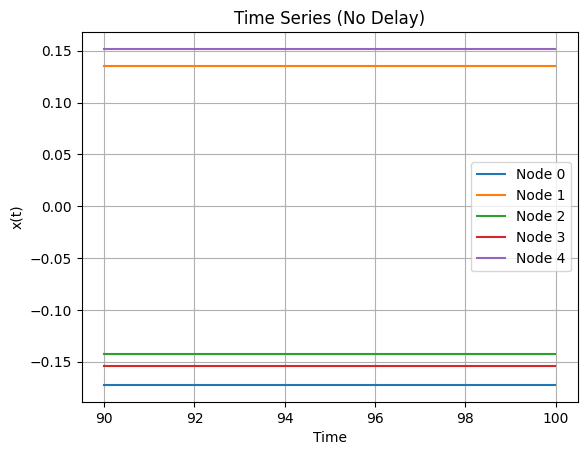

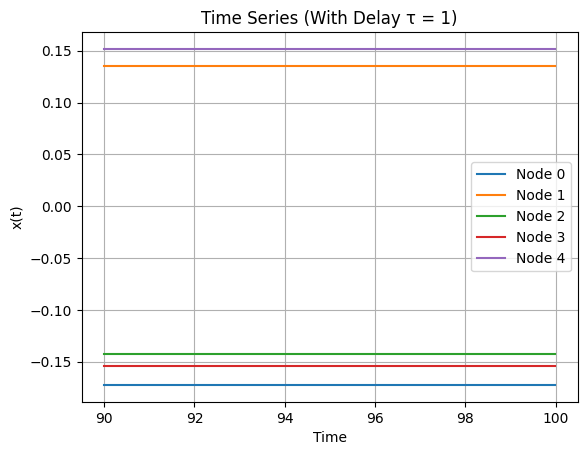

In [6]:
# ---------------- TIME SERIES ----------------
time = np.arange(9000, 10000) * h

# -------- WITHOUT DELAY --------
x_hist_, _, s_hist = simulator(x0, y0, s0, 0, k1, k2, 3,A_ring,A_random)

plt.figure()

for i in range(5):
    plt.plot(time, x_hist_[9000:, i], label=f'Node {i}')

plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Time Series (No Delay)")
plt.legend()
plt.grid(True)
plt.show()


# -------- WITH DELAY --------
x_hist_, _, s_hist= simulator(x0, y0, s0, 0, k1, k2, 3,A_ring,A_random)

plt.figure()

for i in range(5):
    plt.plot(time, x_hist_[9000:, i], label=f'Node {i}')

plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Time Series (With Delay τ = 1)")
plt.legend()
plt.grid(True)
plt.show()

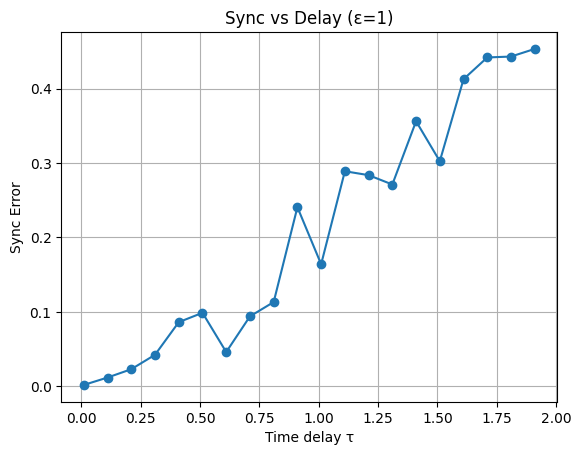

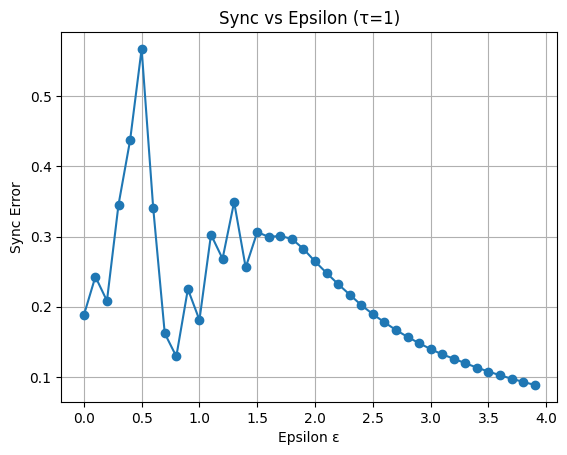

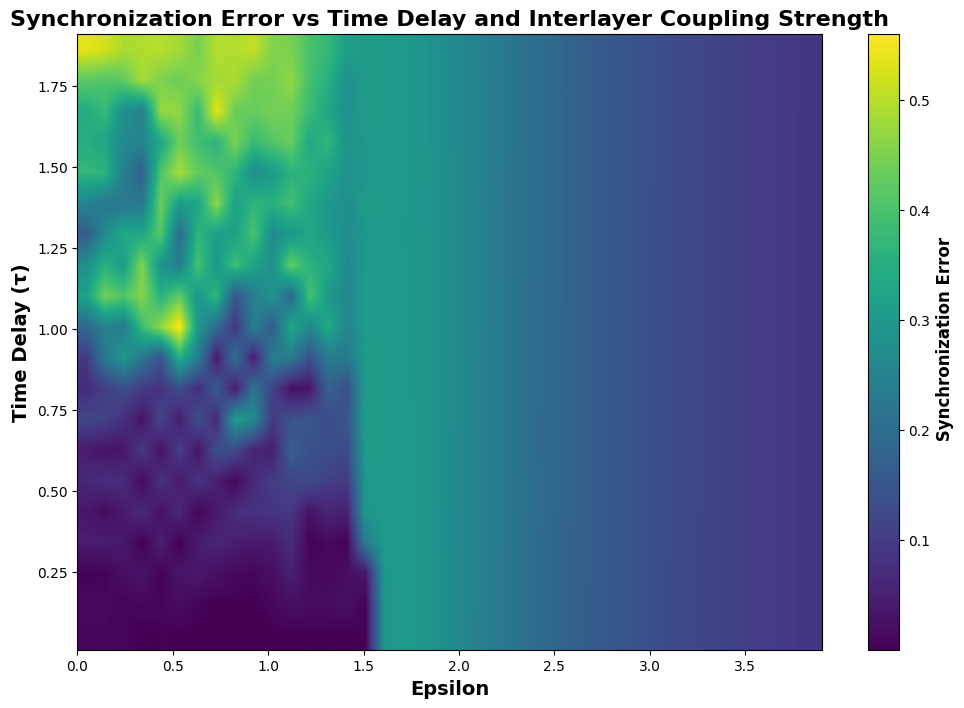

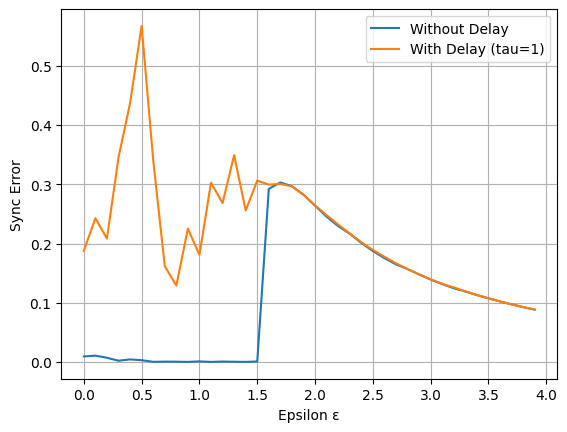

Critical Coupling (no delay): 0.0  and minimum error: 0.00025121539879163323
Critical Coupling (with delay): None and minimum error : 0.08854121094685696


In [7]:
#L1-Watts Strogatz   ,L2-Ring
# Ring with watts strogatz network multiplexed
#(environment is ring and oscillator network  is WS)
#multiplexed network

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
#parameters
N = 100            # number of oscillators
r1 = 5             #for environment
p=0.1         # coupling range for oscillators in layer 2 (connection probability for erdos renyi random network)
omega = 1.0        # natural frequency
h = 0.01          # time step
T = 100           # total time
k1=0.5
k2=0.5
gamma=1  #damping coefficient
steps =int(T / h)

#generate WS network beta=0.3
G_ws = nx.watts_strogatz_graph(N, 2*r1, 0.3)
A_ws=nx.to_numpy_array(G_ws)
degree_ws=np.sum(A_ws,axis=1)
#generate Ring network(Watts strogatz network with beta=0)
G_ring = nx.watts_strogatz_graph(N, 2*r1, 0)
A_ring=nx.to_numpy_array(G_ring)
degree_ring=np.sum(A_ring,axis=1)

#initial conditions with reproducibility
np.random.seed(0)
x0=np.random.uniform(-1,1,N)
y0=np.random.uniform(-1,1,N)
s0=np.random.uniform(-1,1,N)
#tau and k1 values
tau_values = np.arange(0.01, 2, 0.1)
epsilon_values = np.arange(0,4,0.1)
#ODE function
def diff_eqn(x, x_delayed, y,s,epsilon,k2, k1,A_ring,A_ws):
    dx = np.zeros(N)
    dy = np.zeros(N)
    ds  = np.zeros(N)
    sum_1=A_ws@x_delayed-degree_ws*x
    sum_2=A_ring@s-degree_ring*s

    dx = (1 - x**2 - y**2) * x - omega * y + (k1 / np.mean(degree_ws)) * sum_1+epsilon*s
    dy = (1 - x**2 - y**2) * y + omega * x
    ds= -gamma*s-epsilon*x+(k2/np.mean(degree_ring))*sum_2


    return dx, dy,ds


def rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_ws):

    k1_x, k1_y, k1_s = diff_eqn(x,x_delayed, y,s,epsilon, k2, k1,A_ring,A_ws)
    k2_x, k2_y, k2_s = diff_eqn(x + 0.5*h*k1_x,x_delayed, y + 0.5*h*k1_y,s + 0.5*h*k1_s,epsilon, k2, k1,A_ring,A_ws)
    k3_x, k3_y, k3_s = diff_eqn(x + 0.5*h*k2_x,x_delayed, y + 0.5*h*k2_y,s + 0.5*h*k2_s,epsilon, k2, k1,A_ring,A_ws)
    k4_x, k4_y, k4_s = diff_eqn(x + h*k3_x, x_delayed, y + h*k3_y,s + h*k3_s,epsilon, k2, k1,A_ring,A_ws)

    x_new = x + (h / 6) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    y_new = y + (h / 6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    s_new = s + (h / 6) * (k1_s + 2*k2_s + 2*k3_s + k4_s)

    return x_new, y_new, s_new


#to run simulation
def simulator(x0, y0,s0, tau, k1,k2,epsilon,A_ring,A_ws):
    time_delay_steps = int(tau / h)

    x_history = [x0.copy()]
    y_history = [y0.copy()]
    s_history = [s0.copy()]

    for iteration in range(steps - 1):

        if iteration < time_delay_steps:
            x_delayed = x0
        else:
            x_delayed = x_history[iteration - time_delay_steps]

        x = x_history[iteration]
        y = y_history[iteration]
        s=  s_history[iteration]

        xnew, ynew,snew = rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_ws)

        x_history.append(xnew)
        y_history.append(ynew)
        s_history.append(snew)

    return np.array(x_history), np.array(y_history),np.array(s_history)






#synchronisation matrix
sync_matrix = np.zeros((len(tau_values), len(epsilon_values)))

for i in range(len(tau_values)):
    for j in range(len(epsilon_values)):

        x_hist, _,s_hist = simulator(x0, y0,s0, tau_values[i], k1,k2,epsilon_values[j],A_ring,A_ws)


        sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
        #synchronisation error calculated between layers
        sync_matrix[i, j] = sync_error






# SYNC ERROR vs TAU
epsilon_fixed = 1
sync_vs_tau = []

for tau in tau_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau, k1, k2, epsilon_fixed,A_ring,A_ws)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))  # scalar
    sync_vs_tau.append(sync_error)                              # append scalar directly

plt.figure()
plt.plot(tau_values, sync_vs_tau, 'o-')
plt.xlabel('Time delay τ')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Delay (ε={epsilon_fixed})')
plt.grid(True)
plt.show()

# SYNC ERROR vs EPSILON
tau_fixed = 1
sync_vs_epsilon = []

for epsilon in epsilon_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, epsilon,A_ring,A_ws)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))  # scalar
    sync_vs_epsilon.append(sync_error)                          # append scalar directly

plt.figure()
plt.plot(epsilon_values, sync_vs_epsilon, 'o-')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Epsilon (τ={tau_fixed})')
plt.grid(True)
plt.show()


#HEATMAP

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(sync_matrix, aspect='auto', cmap='viridis', origin='lower',
               extent=[epsilon_values[0], epsilon_values[-1], tau_values[0], tau_values[-1]],
               interpolation='bilinear')

ax.set_xlabel('Epsilon', fontsize=14, fontweight='bold')
ax.set_ylabel('Time Delay (τ)', fontsize=14, fontweight='bold')
ax.set_title('Synchronization Error vs Time Delay and Interlayer Coupling Strength',
             fontsize=16, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(' Synchronization Error', fontsize=12, fontweight='bold')

#MINIMUM coupling strenght required
error_without_delay=[]
error_with_delay=[]
#WITHOUT DELAY
for i in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, 0, k1, k2, i,A_ring,A_ws)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_without_delay.append(sync_error)

#WITH DELAY
for j in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, j,A_ring,A_ws)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_with_delay.append(sync_error)

#Plotting
plt.figure()
plt.plot(epsilon_values, error_without_delay, label='Without Delay')
plt.plot(epsilon_values, error_with_delay, label='With Delay (tau=1)')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.legend()
plt.grid(True)
plt.show()

error_ud=np.array(error_without_delay)
error_d=np.array(error_with_delay)
tol=10**(-2)

if np.any(error_ud<tol):
  e_ud=epsilon_values[np.where(error_ud<tol)[0][0]]
else:
  e_ud=None

if np.any(error_d<tol):
  e_d=epsilon_values[np.where(error_d<tol)[0][0]]
else:
  e_d=None

print("Critical Coupling (no delay):",e_ud," and minimum error:",np.min(error_ud))
print("Critical Coupling (with delay):",e_d,"and minimum error :",np.min(error_d))

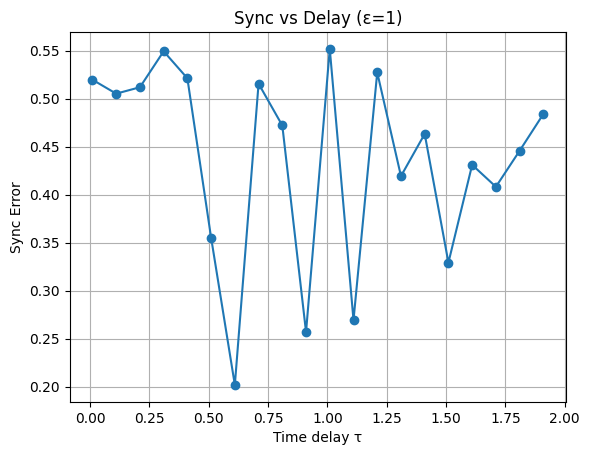

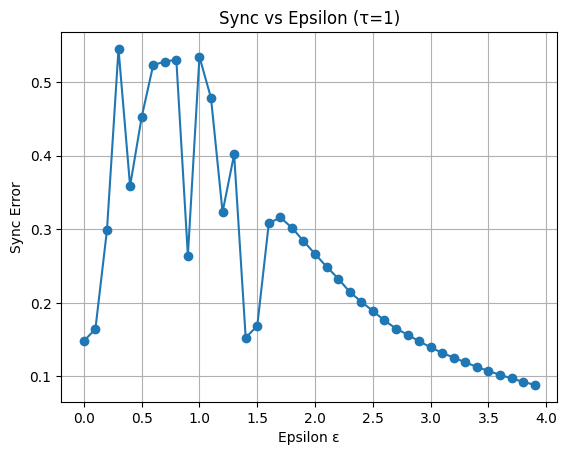

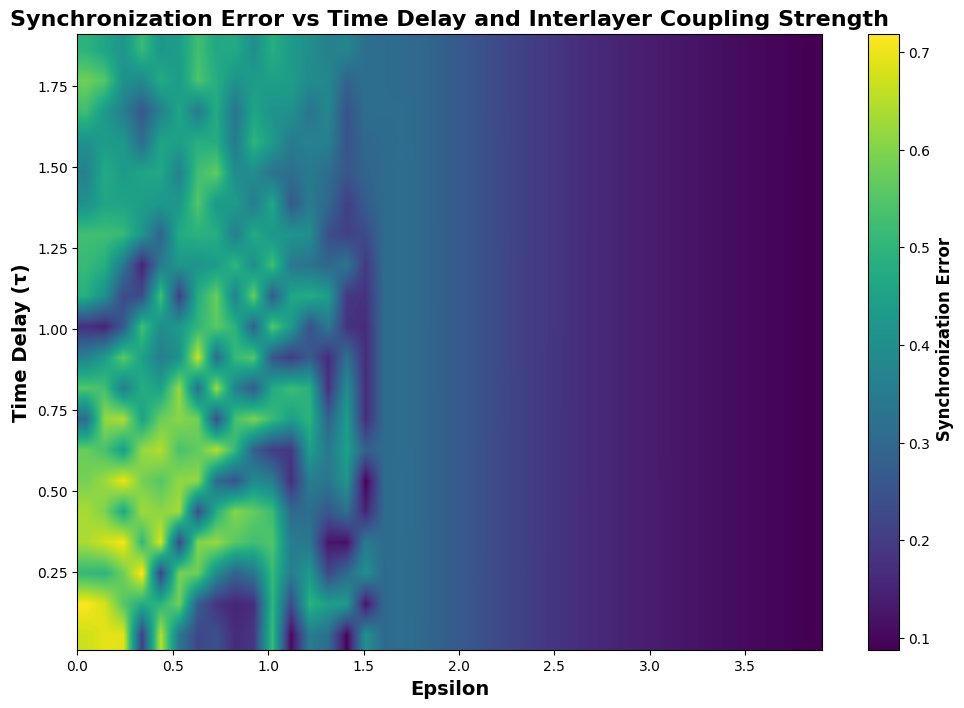

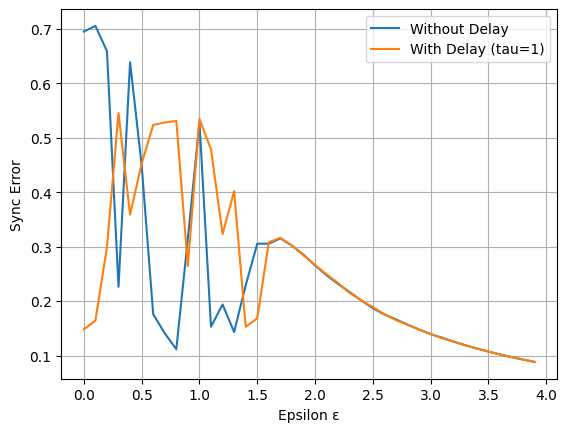

Critical Coupling (no delay): None  and minimum error: 0.08834938092278533
Critical Coupling (with delay): None and minimum error : 0.08834938092278527


In [8]:
#L1-ring,L2-ring
# Ring with ring network multiplexed
#(environment is ring and oscillator Network is ring)
#multiplexed network

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
#parameters
N = 100            # number of oscillators
r1 = 5           #for environment
p=0.1         # coupling range for oscillators in layer 2 (connection probability for erdos renyi random network)
omega = 1.0        # natural frequency
h = 0.01          # time step
T = 100           # total time
k1=0.5
k2=0.5
gamma=1  #damping coefficient
steps =int(T / h)

#generate WS network beta=0
G_ws = nx.watts_strogatz_graph(N, 2*r1, 0)
A_ws=nx.to_numpy_array(G_ws)
degree_ws=np.sum(A_ws,axis=1)
#generate Ring network(Watts strogatz network with beta=0)
G_ring = nx.watts_strogatz_graph(N, 2*r1, 0)
A_ring=nx.to_numpy_array(G_ring)
degree_ring=np.sum(A_ring,axis=1)

#initial conditions with reproducibility
np.random.seed(0)
x0=np.random.uniform(-1,1,N)
y0=np.random.uniform(-1,1,N)
s0=np.random.uniform(-1,1,N)
#tau and k1 values
tau_values = np.arange(0.01, 2, 0.1)
epsilon_values = np.arange(0,4, 0.1)
#ODE function
def diff_eqn(x, x_delayed, y,s,epsilon,k2, k1,A_ring,A_ws):
    dx = np.zeros(N)
    dy = np.zeros(N)
    ds  = np.zeros(N)
    sum_1=A_ws@x_delayed-degree_ws*x
    sum_2=A_ring@s-degree_ring*s

    dx = (1 - x**2 - y**2) * x - omega * y + (k1 / np.mean(degree_ws)) * sum_1+epsilon*s
    dy = (1 - x**2 - y**2) * y + omega * x
    ds= -gamma*s-epsilon*x+(k2/np.mean(degree_ring))*sum_2


    return dx, dy,ds


def rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_ws):

    k1_x, k1_y, k1_s = diff_eqn(x,x_delayed, y,s,epsilon, k2, k1,A_ring,A_ws)
    k2_x, k2_y, k2_s = diff_eqn(x + 0.5*h*k1_x,x_delayed, y + 0.5*h*k1_y,s + 0.5*h*k1_s,epsilon, k2, k1,A_ring,A_ws)
    k3_x, k3_y, k3_s = diff_eqn(x + 0.5*h*k2_x,x_delayed, y + 0.5*h*k2_y,s + 0.5*h*k2_s,epsilon, k2, k1,A_ring,A_ws)
    k4_x, k4_y, k4_s = diff_eqn(x + h*k3_x, x_delayed, y + h*k3_y,s + h*k3_s,epsilon, k2, k1,A_ring,A_ws)

    x_new = x + (h / 6) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    y_new = y + (h / 6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    s_new = s + (h / 6) * (k1_s + 2*k2_s + 2*k3_s + k4_s)

    return x_new, y_new, s_new


#to run simulation
def simulator(x0, y0,s0, tau, k1,k2,epsilon,A_ring,A_ws):
    time_delay_steps = int(tau / h)

    x_history = [x0.copy()]
    y_history = [y0.copy()]
    s_history = [s0.copy()]

    for iteration in range(steps - 1):

        if iteration < time_delay_steps:
            x_delayed = x0
        else:
            x_delayed = x_history[iteration - time_delay_steps]

        x = x_history[iteration]
        y = y_history[iteration]
        s=  s_history[iteration]

        xnew, ynew,snew = rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_ws)

        x_history.append(xnew)
        y_history.append(ynew)
        s_history.append(snew)

    return np.array(x_history), np.array(y_history),np.array(s_history)






#synchronisation matrix
sync_matrix = np.zeros((len(tau_values), len(epsilon_values)))

for i in range(len(tau_values)):
    for j in range(len(epsilon_values)):

        x_hist, _,s_hist = simulator(x0, y0,s0, tau_values[i], k1,k2,epsilon_values[j],A_ring,A_ws)


        sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))

        sync_matrix[i, j] = sync_error







# SYNC ERROR vs TAU
epsilon_fixed = 1
sync_vs_tau = []

for tau in tau_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau, k1, k2, epsilon_fixed,A_ring,A_ws)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1]))) # scalar
    sync_vs_tau.append(sync_error)                              # append scalar directly

plt.figure()
plt.plot(tau_values, sync_vs_tau, 'o-')
plt.xlabel('Time delay τ')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Delay (ε={epsilon_fixed})')
plt.grid(True)
plt.show()

# SYNC ERROR vs EPSILON
tau_fixed = 1
sync_vs_epsilon = []

for epsilon in epsilon_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, epsilon,A_ring,A_ws)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))  # scalar
    sync_vs_epsilon.append(sync_error)                          # append scalar directly

plt.figure()
plt.plot(epsilon_values, sync_vs_epsilon, 'o-')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Epsilon (τ={tau_fixed})')
plt.grid(True)
plt.show()


#HEATMAP

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(sync_matrix, aspect='auto', cmap='viridis', origin='lower',
               extent=[epsilon_values[0], epsilon_values[-1], tau_values[0], tau_values[-1]],
               interpolation='bilinear')

ax.set_xlabel('Epsilon', fontsize=14, fontweight='bold')
ax.set_ylabel('Time Delay (τ)', fontsize=14, fontweight='bold')
ax.set_title('Synchronization Error vs Time Delay and Interlayer Coupling Strength',
             fontsize=16, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(' Synchronization Error', fontsize=12, fontweight='bold')

#MINIMUM coupling strength required
error_without_delay=[]
error_with_delay=[]
#WITHOUT DELAY
for i in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, 0, k1, k2, i,A_ring,A_ws)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_without_delay.append(sync_error)

#WITH DELAY
for j in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, j,A_ring,A_ws)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_with_delay.append(sync_error)

#Plotting
plt.figure()
plt.plot(epsilon_values, error_without_delay, label='Without Delay')
plt.plot(epsilon_values, error_with_delay, label='With Delay (tau=1)')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.legend()
plt.grid(True)
plt.show()

error_ud=np.array(error_without_delay)
error_d=np.array(error_with_delay)
tol=10**(-2)

if np.any(error_ud<tol):
  e_ud=epsilon_values[np.where(error_ud<tol)[0][0]]
else:
  e_ud=None

if np.any(error_d<tol):
  e_d=epsilon_values[np.where(error_d<tol)[0][0]]
else:
  e_d=None

print("Critical Coupling (no delay):",e_ud," and minimum error:",np.min(error_ud))
print("Critical Coupling (with delay):",e_d,"and minimum error :",np.min(error_d))

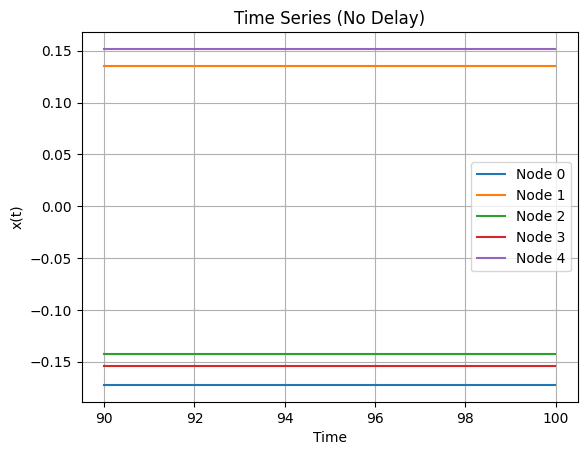

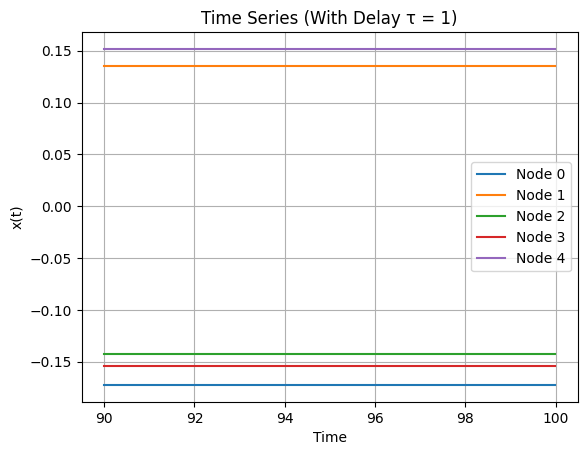

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# ---------------- TIME SERIES ----------------
time = np.arange(9000, 10000) * h

# -------- WITHOUT DELAY --------
x_hist, _, s_hist = simulator(x0, y0, s0, 0, k1, k2, 3,A_ring,A_ws)

plt.figure()

for i in range(5):
    plt.plot(time, x_hist_[9000:, i], label=f'Node {i}')

plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Time Series (No Delay)")
plt.legend()
plt.grid(True)
plt.show()


# -------- WITH DELAY --------
x_hist, _, s_hist = simulator(x0, y0, s0, 1, k1, k2, 3,A_ring,A_ws)

plt.figure()

for i in range(5):
    plt.plot(time, x_hist_[9000:, i], label=f'Node {i}')

plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Time Series (With Delay τ = 1)")
plt.legend()
plt.grid(True)
plt.show()

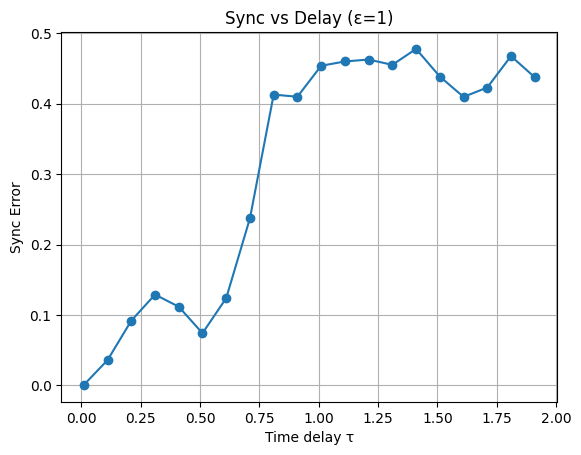

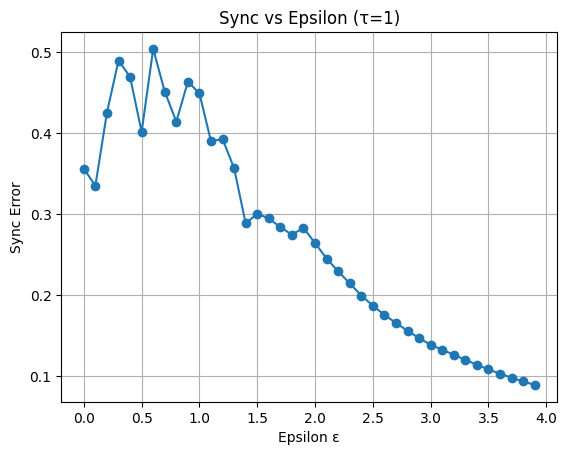

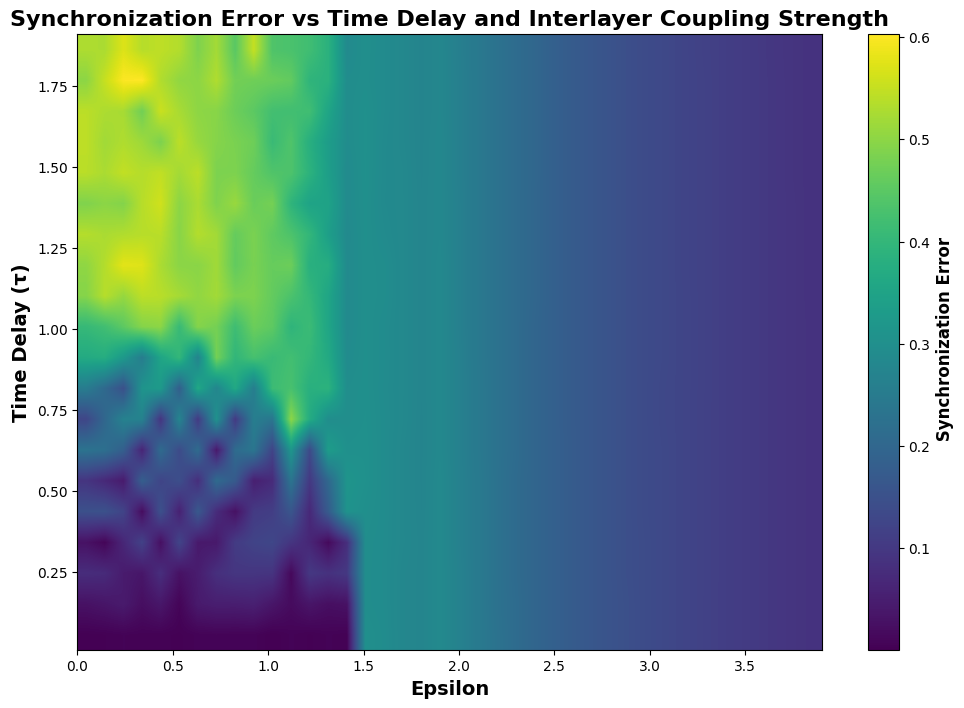

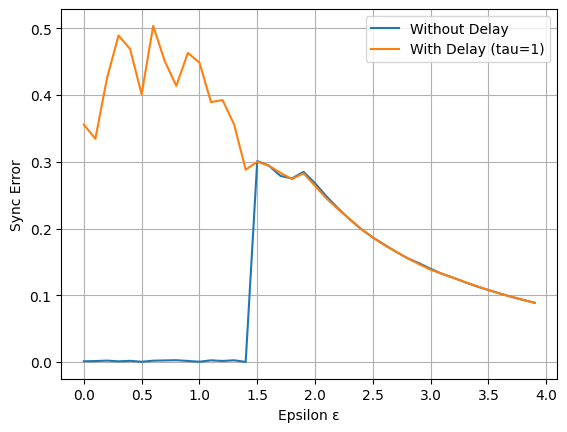

Critical Coupling (no delay): 0.0  and minimum error: 0.00011570563551887791
Critical Coupling (with delay): None and minimum error : 0.08872254635024839


In [10]:
#L1- ring, L2-BA
# Ring with BA network multiplexed
#(environment is ring and oscillator Network is BA)
#multiplexed network

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
#parameters
N = 100            # number of oscillators
r1 = 5
m=5
omega = 1.0        # natural frequency
h = 0.01          # time step
T = 100           # total time
k1=0.5
k2=0.5
gamma=1  #damping coefficient
steps =int(T / h)

#generate BA network
G_ba = nx.barabasi_albert_graph(N, m, seed=0)
A_ba=nx.to_numpy_array(G_ba)
degree_ba=np.sum(A_ba,axis=1)
#generate Ring network(Watts strogatz network with beta=0)
G_ring = nx.watts_strogatz_graph(N, 2*r1, 0)
A_ring=nx.to_numpy_array(G_ring)
degree_ring=np.sum(A_ring,axis=1)

#initial conditions with reproducibility
np.random.seed(0)
x0=np.random.uniform(-1,1,N)
y0=np.random.uniform(-1,1,N)
s0=np.random.uniform(-1,1,N)
#tau and k1 values
tau_values = np.arange(0.01, 2, 0.1)
epsilon_values = np.arange(0,4, 0.1)
#ODE function
def diff_eqn(x, x_delayed, y,s,epsilon,k2, k1,A_ring,A_ba):
    dx = np.zeros(N)
    dy = np.zeros(N)
    ds  = np.zeros(N)
    sum_1=A_ba@x_delayed-degree_ba*x
    sum_2=A_ring@s-degree_ring*s

    dx = (1 - x**2 - y**2) * x- omega * y + (k1 / np.mean(degree_ba)) * sum_1+epsilon*s
    dy = (1 - x**2 - y**2) * y + omega * x
    ds= -gamma*s-epsilon*x+(k2/np.mean(degree_ring))*sum_2


    return dx, dy,ds


def rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_ba):

    k1_x, k1_y, k1_s = diff_eqn(x,x_delayed, y,s,epsilon, k2, k1,A_ring,A_ba)
    k2_x, k2_y, k2_s = diff_eqn(x + 0.5*h*k1_x,x_delayed, y + 0.5*h*k1_y,s + 0.5*h*k1_s,epsilon, k2, k1,A_ring,A_ba)
    k3_x, k3_y, k3_s = diff_eqn(x + 0.5*h*k2_x,x_delayed, y + 0.5*h*k2_y,s + 0.5*h*k2_s,epsilon, k2, k1,A_ring,A_ba)
    k4_x, k4_y, k4_s = diff_eqn(x + h*k3_x, x_delayed, y + h*k3_y,s + h*k3_s,epsilon, k2, k1,A_ring,A_ba)

    x_new = x + (h / 6) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    y_new = y + (h / 6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    s_new = s + (h / 6) * (k1_s + 2*k2_s + 2*k3_s + k4_s)

    return x_new, y_new, s_new


#to run simulation
def simulator(x0, y0,s0, tau, k1,k2,epsilon,A_ring,A_ba):
    time_delay_steps = int(tau / h)

    x_history = [x0.copy()]
    y_history = [y0.copy()]
    s_history = [s0.copy()]

    for iteration in range(steps - 1):

        if iteration < time_delay_steps:
            x_delayed = x0
        else:
            x_delayed = x_history[iteration - time_delay_steps]

        x = x_history[iteration]
        y = y_history[iteration]
        s=  s_history[iteration]

        xnew, ynew,snew = rk4(x, x_delayed, y, s, epsilon, k2, k1,A_ring,A_ba)

        x_history.append(xnew)
        y_history.append(ynew)
        s_history.append(snew)

    return np.array(x_history), np.array(y_history),np.array(s_history)




#synchronisation matrix
sync_matrix = np.zeros((len(tau_values), len(epsilon_values)))

for i in range(len(tau_values)):
    for j in range(len(epsilon_values)):

        x_hist, _,s_hist = simulator(x0, y0,s0, tau_values[i], k1,k2,epsilon_values[j],A_ring,A_ba)


        sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
        sync_matrix[i, j] = sync_error

#plotting


# SYNC ERROR vs TAU
epsilon_fixed = 1
sync_vs_tau = []

for tau in tau_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau, k1, k2, epsilon_fixed,A_ring,A_ba)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))  # scalar
    sync_vs_tau.append(sync_error)                              # append scalar directly

plt.figure()
plt.plot(tau_values, sync_vs_tau, 'o-')
plt.xlabel('Time delay τ')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Delay (ε={epsilon_fixed})')
plt.grid(True)
plt.show()

# SYNC ERROR vs EPSILON
tau_fixed = 1
sync_vs_epsilon = []

for epsilon in epsilon_values:
    x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, epsilon,A_ring,A_ba)
    sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))  # scalar
    sync_vs_epsilon.append(sync_error)                          # append scalar directly

plt.figure()
plt.plot(epsilon_values, sync_vs_epsilon, 'o-')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.title(f'Sync vs Epsilon (τ={tau_fixed})')
plt.grid(True)
plt.show()


#HEATMAP

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(sync_matrix, aspect='auto', cmap='viridis', origin='lower',
               extent=[epsilon_values[0], epsilon_values[-1], tau_values[0], tau_values[-1]],
               interpolation='bilinear')

ax.set_xlabel('Epsilon', fontsize=14, fontweight='bold')
ax.set_ylabel('Time Delay (τ)', fontsize=14, fontweight='bold')
ax.set_title('Synchronization Error vs Time Delay and Interlayer Coupling Strength',
             fontsize=16, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(' Synchronization Error', fontsize=12, fontweight='bold')

#MINIMUM coupling strenght required
error_without_delay=[]
error_with_delay=[]
#WITHOUT DELAY
for i in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, 0, k1, k2, i,A_ring,A_ba)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_without_delay.append(sync_error)

#WITH DELAY
for j in epsilon_values:

  x_hist, _, s_hist = simulator(x0, y0, s0, tau_fixed, k1, k2, j,A_ring,A_ba)
  sync_error = sync_error = np.mean(np.abs(x_hist[-1] - np.mean(x_hist[-1])))
  error_with_delay.append(sync_error)

#Plotting
plt.figure()
plt.plot(epsilon_values, error_without_delay, label='Without Delay')
plt.plot(epsilon_values, error_with_delay, label='With Delay (tau=1)')
plt.xlabel('Epsilon ε')
plt.ylabel('Sync Error')
plt.legend()
plt.grid(True)
plt.show()

error_ud=np.array(error_without_delay)
error_d=np.array(error_with_delay)
tol=10**(-2)

if np.any(error_ud<tol):
  e_ud=epsilon_values[np.where(error_ud<tol)[0][0]]
else:
  e_ud=None

if np.any(error_d<tol):
  e_d=epsilon_values[np.where(error_d<tol)[0][0]]
else:
  e_d=None

print("Critical Coupling (no delay):",e_ud," and minimum error:",np.min(error_ud))
print("Critical Coupling (with delay):",e_d,"and minimum error :",np.min(error_d))